## **Assignment Two (EECS3404 W26)**

**your name:** \\
**your student number:** \\
**your yorku email:**

This assignment is mainly for you to review linear models. You have to work individually. Remember to fill in your information (name, student number, email) at above.



##**What to Submit**

Please use this notebook to complete this assignment. You have to run your codes and show the results in this notebook. Download the completed notenook as `.ipynb` and compress it as a `.zip` file to submit to eClass.  Submit only ONE notebook file that contains all of your answers and codes to eClass before the deadline.  No late submission
will be accepted.

* For all written parts, write your answers in text cells. To avoid confusions in marking, better to embed latex codes there to represent all mathematical notations and equations.  **No handwriting is accepted**.

* For programming parts, you should give codes, comments, explanations and the proper running outputs in both code and text cells. Make your jupyter notebook clean and concise. Remove all unused codes and all intermediate results from the submitted notebook. The submitted notebook should include only the final (best) outputs for each question. Also make sure every code cell runnable so that markers can reproduce the outputs if necessary.

### **Q1** (50 marks)  **Linear Regression** ###

Part 1.1 (20 marks): Write a Python function that performs linear regression using gradient descent. The function should take NumPy arrays X (features with a column of ones for the intercept) and y (target) as input, along with the learning rate alpha and the number of iterations. Return the learned coefficients (weights) as a NumPy array.

Requirements:
- Minimize the Mean Squared Error (MSE) loss function: $L(\theta)=\frac{1}{2m} \sum_{i=1}^m (h_\theta(x^{(i)})-y^{(i)})^2$ where $h_\theta(x)= \mathbf{X} \theta$
 is the prediction and  $m$ is the number of samples. The factor of $\frac{1}{2}$ simplifies the gradient calculation.
- Initialize all weights to zero
- Use gradient descent (use all samples in each iteration).
The input matrix X has shape $(m, n)$ where $m$ is the number of training examples and $n$ is the number of features (including the bias column of ones). The target vector y has shape $(m,)$.


In [4]:
import numpy as np
import jax.numpy as jnp

def linear_regression_gradient_descent(X: jnp.ndarray, y: jnp.ndarray, alpha: float, iterations: int) -> np.ndarray:
    # Your code here, make sure to round
    m, n = X.shape
    theta = np.zeros((n, 1))
    for _ in range(iterations):
        h = X @ theta                        # Predictions: shape (m,)
        gradient = (1 / m) * X.T @ (h - y)  # Gradient of MSE w.r.t. theta
        theta = theta - alpha * gradient     # Update rule
    return np.round(theta, 4)

Part 1.2 (20 marks): Write a Python function `ridge_loss` that implements the Ridge Regression loss function. The function should take a 2D numpy array $\mathbf{X}$ representing the feature matrix, a 1D numpy array $w$ representing the coefficients, a 1D numpy array $y_{true}$ representing the true labels, and a float alpha representing the regularization parameter. The function should return the Ridge loss, which combines the Mean Squared Error (MSE) and a regularization term.


Example:

Input:
```
import numpy as np

X = np.array([[1, 1], [2, 1], [3, 1], [4, 1]])
w = np.array([0.2, 2])
y_true = np.array([2, 3, 4, 5])
alpha = 0.1

loss = ridge_loss(w, X, y_true, alpha)
print(loss)
```
Output:


```
2.204
```




In [5]:
# Write your code for Q1.2 here
import numpy as np
import jax.numpy as jnp

def ridge_loss(w: jnp.ndarray, X: jnp.ndarray, y_true: jnp.ndarray, alpha: float) -> float:
    m = len(y_true)
    predictions = X @ w
    mse = (1 / m) * np.sum((predictions - y_true) ** 2)
    regularization = alpha * np.sum(w ** 2)
    return round(mse + regularization, 4)

X = np.array([[1, 1], [2, 1], [3, 1], [4, 1]])
w = np.array([0.2, 2])
y_true = np.array([2, 3, 4, 5])
alpha = 0.1

loss = ridge_loss(w, X, y_true, alpha)
print(loss)

2.204


Part 1.3 (10 marks):
1. Following the linear regression implementation in [Project 2,](https://colab.research.google.com/drive/1_l8Mqn3Bz66cqVBOhlHftM9jNjhQL_en?usp=sharing) use mini-batch SGD (with auto-grad and a batch size=55) to implement the Ridge regression for the binary classification task of digits ('1' and '7') in MNIST. Use the objective function from Part 1.2
2. Apply the closed-form solution of Ridge regression as well as the linear regression method from Part 1.1 on the binary classification task of digits ('1' and '7') in MNIST.
3. Compare the results from Part 1.3.1 and Part 1.3.2 in terms of convergence rate and classification accuracy.

Mini-batch SGD Ridge accuracy : 1.0000
Closed-form Ridge accuracy    : 1.0000
Linear Regression GD accuracy : 1.0000


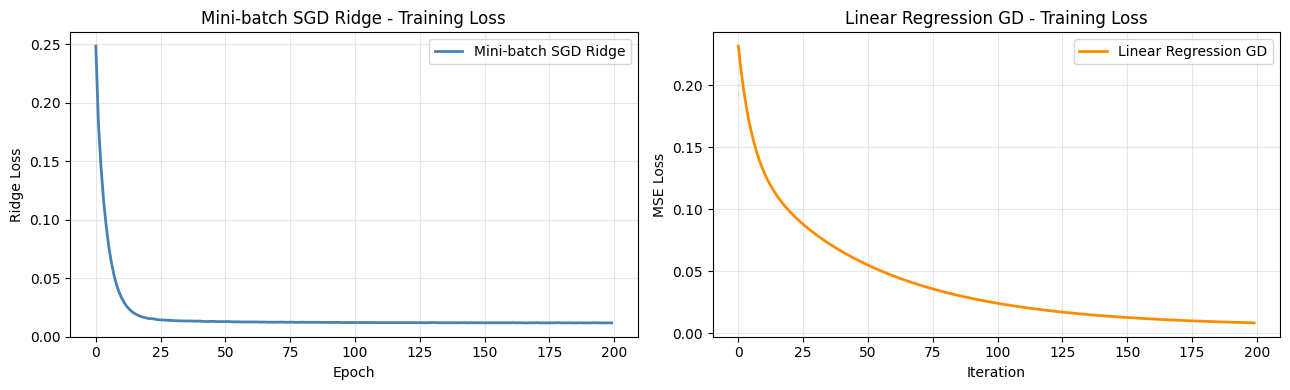

In [6]:
# Write your code for Q1.3 here
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score

digits = load_digits()
mask = (digits.target == 1) | (digits.target == 7)
X_raw = digits.data[mask].astype(float)
y_raw = (digits.target[mask] == 7).astype(float)

X_bias = np.hstack([X_raw, np.ones((len(X_raw), 1))])
X_tr, X_te, y_tr, y_te = train_test_split(X_bias, y_raw, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_tr[:, :-1] = scaler.fit_transform(X_tr[:, :-1])
X_te[:, :-1] = scaler.transform(X_te[:, :-1])

def ridge_gradient(w, X, y, alpha_reg):
    m = len(y)
    residuals = X @ w - y
    return (2 / m) * X.T @ residuals + 2 * alpha_reg * w

def mini_batch_sgd_ridge(X, y, alpha_reg=0.01, lr=0.01, epochs=200, batch_size=55, seed=42):
    rng = np.random.default_rng(seed)
    m, n = X.shape
    w = np.zeros(n)
    losses = []
    for _ in range(epochs):
        idx = rng.permutation(m)
        Xs, ys = X[idx], y[idx]
        for start in range(0, m, batch_size):
            Xb, yb = Xs[start:start+batch_size], ys[start:start+batch_size]
            w -= lr * ridge_gradient(w, Xb, yb, alpha_reg)
        losses.append(ridge_loss(w, X, y, alpha_reg))
    return w, losses

def ridge_closed_form(X, y, alpha_reg=0.01):
    n = X.shape[1]
    I = np.eye(n)
    I[-1, -1] = 0
    return np.linalg.solve(X.T @ X + alpha_reg * I, X.T @ y)

def linreg_gd_with_loss(X, y, alpha=0.01, iterations=200):
    m, n = X.shape
    w = np.zeros(n)
    losses = []
    for _ in range(iterations):
        h = X @ w
        w -= (alpha / m) * X.T @ (h - y)
        losses.append((1 / (2 * m)) * np.sum((X @ w - y) ** 2))
    return w, losses

w_sgd, losses_sgd = mini_batch_sgd_ridge(X_tr, y_tr)
acc_sgd = accuracy_score(y_te, (X_te @ w_sgd >= 0.5).astype(float))
print(f"Mini-batch SGD Ridge accuracy : {acc_sgd:.4f}")

w_cf = ridge_closed_form(X_tr, y_tr)
acc_cf = accuracy_score(y_te, (X_te @ w_cf >= 0.5).astype(float))
print(f"Closed-form Ridge accuracy    : {acc_cf:.4f}")

w_lr, losses_lr = linreg_gd_with_loss(X_tr, y_tr)
acc_lr = accuracy_score(y_te, (X_te @ w_lr >= 0.5).astype(float))
print(f"Linear Regression GD accuracy : {acc_lr:.4f}")

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].plot(losses_sgd, color='steelblue', lw=2, label='Mini-batch SGD Ridge')
axes[0].set_title('Mini-batch SGD Ridge - Training Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Ridge Loss')
axes[0].legend()
axes[0].grid(alpha=0.3)
axes[1].plot(losses_lr, color='darkorange', lw=2, label='Linear Regression GD')
axes[1].set_title('Linear Regression GD - Training Loss')
axes[1].set_xlabel('Iteration')
axes[1].set_ylabel('MSE Loss')
axes[1].legend()
axes[1].grid(alpha=0.3)
plt.tight_layout()
plt.show()

### **Q2** (40 marks)  **Dimensionality Reduction** ###
In this question, use the sklearn library.

Part 2.1 (10 marks): Load the dataset [load_breast_cancer](https://scikit-learn.org/stable/modules/generated/sklearn.datasets.load_breast_cancer.html).
1. Split the dataset into training and testing sets (80/20).
2. Standardize all numerical features using a standard scaler.

In [13]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# ── Load dataset ──────────────────────────────────────────────────────────────
data = load_breast_cancer()
X, y = data.data, data.target

print(f"Dataset shape : {X.shape}  (samples × features)")
print(f"Classes       : {data.target_names}  →  0=malignant, 1=benign")
print(f"Class counts  : malignant={( y==0).sum()}, benign={(y==1).sum()}")

# ── 80/20 train-test split ────────────────────────────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
print(f"\nTrain size : {X_train.shape[0]}  |  Test size : {X_test.shape[0]}")

# ── Standardize features (fit on train, apply to test) ───────────────────────
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)   # mean=0, std=1 per feature
X_test_sc  = scaler.transform(X_test)

print(f"After scaling – Train mean ≈ {X_train_sc.mean():.6f}, std ≈ {X_train_sc.std():.4f}")
print(f"After scaling – Test  mean ≈ {X_test_sc.mean():.4f},  std ≈ {X_test_sc.std():.4f}")

Dataset shape : (569, 30)  (samples × features)
Classes       : ['malignant' 'benign']  →  0=malignant, 1=benign
Class counts  : malignant=212, benign=357

Train size : 455  |  Test size : 114
After scaling – Train mean ≈ -0.000000, std ≈ 1.0000
After scaling – Test  mean ≈ 0.0319,  std ≈ 0.9685


Part 2.2 (10 marks):
1. Fit PCA on the training data only.
2. Print the explained variance ratio for each component.
  - Expected output format:
      ```
          Explained variance ratio per component:
              PC1: 0.36
              PC2: 0.19
              PC3: 0.13
      ```
  - Note: the numbers given in this example are random and are not expected to match the actual numbers from the dataset
3. Plot the cumulative variance where the x-axis is  component number and the y-axis is the cumulative variance. Add a horizontal line at 95 % of the cumulative variance.
4. Choose the number of components needed to retain at least 95% of variance.
5. Transform train/test data into this PCA space. Print the new shapes of your training and testing sets.

Explained variance ratio per component:
    PC1: 0.44
    PC2: 0.20
    PC3: 0.10
    PC4: 0.06
    PC5: 0.05
    PC6: 0.04
    PC7: 0.02
    PC8: 0.02
    PC9: 0.01
    PC10: 0.01
    PC11: 0.01
    PC12: 0.01
    PC13: 0.01
    PC14: 0.01
    PC15: 0.00
    PC16: 0.00
    PC17: 0.00
    PC18: 0.00
    PC19: 0.00
    PC20: 0.00
    PC21: 0.00
    PC22: 0.00
    PC23: 0.00
    PC24: 0.00
    PC25: 0.00
    PC26: 0.00
    PC27: 0.00
    PC28: 0.00
    PC29: 0.00
    PC30: 0.00


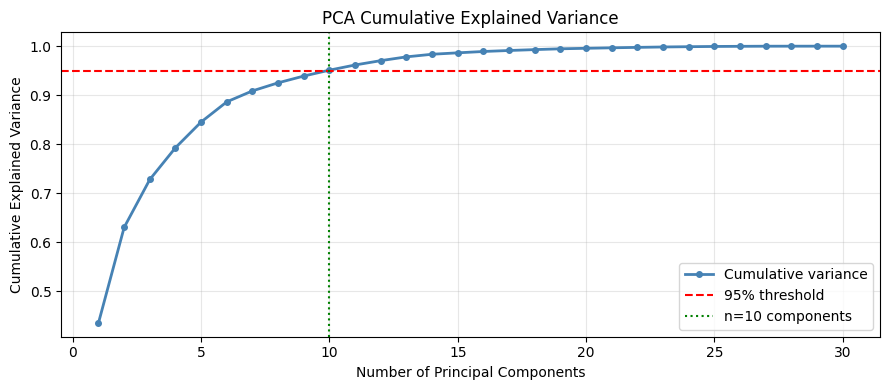


Components needed to retain 95% variance: 10
New training set shape : (455, 10)
New test set shape     : (114, 10)


In [9]:
# Write your code for Q2.2 here
from sklearn.decomposition import PCA

pca_full = PCA(random_state=42)
pca_full.fit(X_train_sc)

evr = pca_full.explained_variance_ratio_
print("Explained variance ratio per component:")
for i, v in enumerate(evr):
    print(f"    PC{i+1}: {v:.2f}")

cumvar = np.cumsum(evr)
n_components_95 = int(np.argmax(cumvar >= 0.95)) + 1

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(range(1, len(cumvar) + 1), cumvar, marker='o', markersize=4, color='steelblue', lw=2, label='Cumulative variance')
ax.axhline(0.95, color='red', linestyle='--', lw=1.5, label='95% threshold')
ax.axvline(n_components_95, color='green', linestyle=':', lw=1.5, label=f'n={n_components_95} components')
ax.set_xlabel('Number of Principal Components')
ax.set_ylabel('Cumulative Explained Variance')
ax.set_title('PCA Cumulative Explained Variance')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

pca = PCA(n_components=n_components_95, random_state=42)
X_train_pca = pca.fit_transform(X_train_sc)
X_test_pca = pca.transform(X_test_sc)

print(f"\nComponents needed to retain 95% variance: {n_components_95}")
print(f"New training set shape : {X_train_pca.shape}")
print(f"New test set shape     : {X_test_pca.shape}")

Part 2.3 (10 marks):
1. Fit LDA on training data.
2. Reduce to the maximum possible number of components.
3. Visualize the transformed data (2D scatterplot colored by class).
4. Compare visually the LDA projection to the PCA 2D projection.

LDA number of components: 1


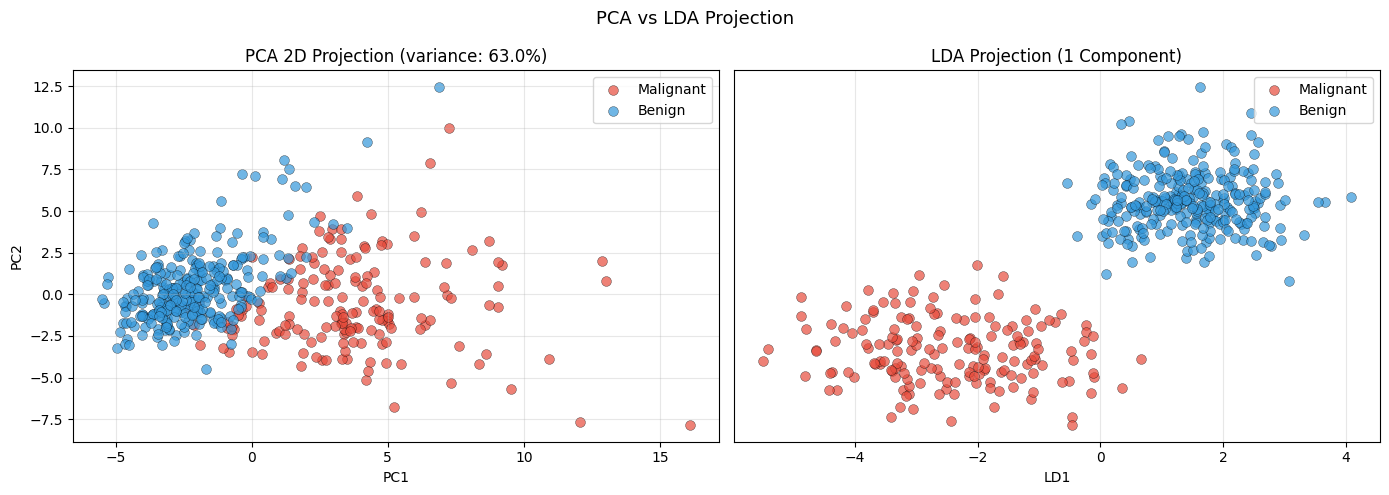

In [11]:
# Write your code for Q2.3 here
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

lda = LinearDiscriminantAnalysis()
X_train_lda = lda.fit_transform(X_train_sc, y_train)
X_test_lda = lda.transform(X_test_sc)

print(f"LDA number of components: {X_train_lda.shape[1]}")

colours = {0: '#e74c3c', 1: '#3498db'}
class_labels = {0: 'Malignant', 1: 'Benign'}

pca_2d = PCA(n_components=2, random_state=42)
X_tr_pca2 = pca_2d.fit_transform(X_train_sc)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for cls in [0, 1]:
    mask = y_train == cls
    axes[0].scatter(X_tr_pca2[mask, 0], X_tr_pca2[mask, 1],
                    c=colours[cls], label=class_labels[cls], alpha=0.7, edgecolors='k', lw=0.3, s=50)
axes[0].set_title(f"PCA 2D Projection (variance: {pca_2d.explained_variance_ratio_.sum()*100:.1f}%)")
axes[0].set_xlabel("PC1")
axes[0].set_ylabel("PC2")
axes[0].legend()
axes[0].grid(alpha=0.3)

for cls in [0, 1]:
    mask = y_train == cls
    jitter = np.random.randn(mask.sum()) * 0.01
    axes[1].scatter(X_train_lda[mask, 0], np.zeros(mask.sum()) + cls * 0.05 + jitter,
                    c=colours[cls], label=class_labels[cls], alpha=0.7, edgecolors='k', lw=0.3, s=50)
axes[1].set_title("LDA Projection (1 Component)")
axes[1].set_xlabel("LD1")
axes[1].set_yticks([])
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.suptitle("PCA vs LDA Projection", fontsize=13)
plt.tight_layout()
plt.show()

Part 2.4 (10 marks):
1. Using KNN train and evaluate three models:
  * Baseline (KNN with no dimensionality reduction)
  * PCA + Classifier (using the components chosen in 2.2)
  * LDA + Classifier
2. Report the accuracy, the running time and the [confusion matrix](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.confusion_matrix.html) for each model.

Baseline (no DR)       Accuracy: 0.9474   Time: 44.819 ms
Confusion Matrix:
[[40  3]
 [ 3 68]]

PCA + KNN              Accuracy: 0.9561   Time: 10.006 ms
Confusion Matrix:
[[40  3]
 [ 2 69]]

LDA + KNN              Accuracy: 0.9386   Time: 4.381 ms
Confusion Matrix:
[[42  1]
 [ 6 65]]



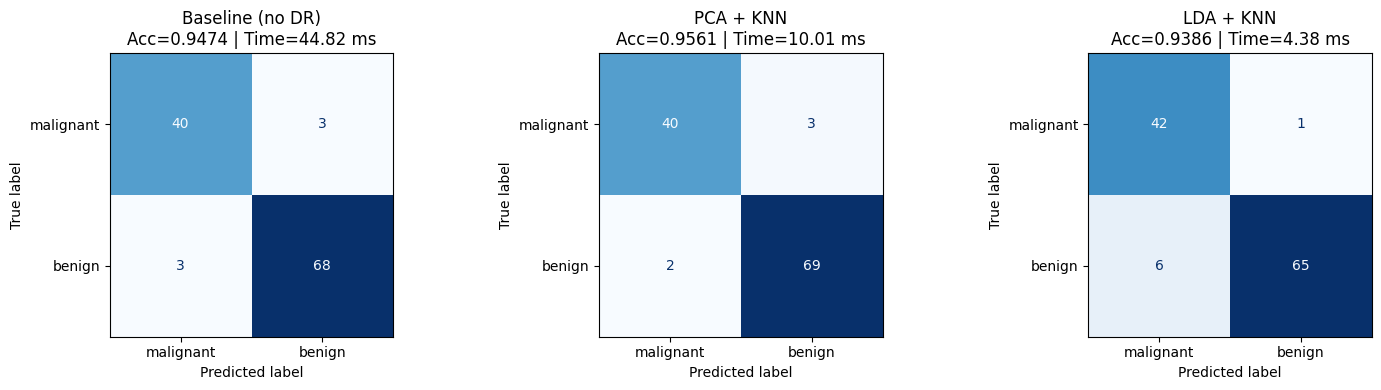

In [12]:
# Write your code for 2.4
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import confusion_matrix, accuracy_score, ConfusionMatrixDisplay
import time

configs = {
    "Baseline (no DR)": (X_train_sc,  X_test_sc),
    "PCA + KNN":        (X_train_pca, X_test_pca),
    "LDA + KNN":        (X_train_lda, X_test_lda),
}

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, (name, (Xtr, Xte)) in zip(axes, configs.items()):
    knn = KNeighborsClassifier(n_neighbors=5)
    t0 = time.perf_counter()
    knn.fit(Xtr, y_train)
    y_pred = knn.predict(Xte)
    elapsed = time.perf_counter() - t0
    acc = accuracy_score(y_test, y_pred)
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(cm, display_labels=data.target_names)
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(f"{name}\nAcc={acc:.4f} | Time={elapsed*1000:.2f} ms")
    print(f"{name:<22} Accuracy: {acc:.4f}   Time: {elapsed*1000:.3f} ms")
    print(f"Confusion Matrix:\n{cm}\n")

plt.tight_layout()
plt.show()